In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")

# Regelstudienzeit

In [3]:
df_alle = pd.read_csv(r"./Projekt/data_excels/Studierende insgesamt(inclu. Beurlaubte)/Studierende insgesamt.csv")
df_regelzeit = pd.read_csv(r"./Projekt/data_excels/Studierende in der Regelstudienzeit/Studierende in der Regelstudienzeit.csv")

In [4]:
# Einheitliche Bennenung von letztlich zusammengeführten Studiengängen
info_idx = df_alle.loc[lambda x: x["Studienfach"].str.contains("Data|Informatik", regex=True)].index     # Data Science, Data Analytics & Informatik
geo_idx = df_alle.loc[lambda x: x["Studienfach"].str.contains("Geo|Erdk", regex=True)].index             # Geographie & Erdkunde

df_alle.loc[geo_idx, "Studienfach"] = "Geograph. / Erdk."
df_alle.loc[info_idx, "Studienfach"] = "Data Sc.|Analyt. / Informatik"

In [5]:
# Alle Werte in ein df
df_grp = (
    df_alle
    .assign(Koepfe_Regel = df_regelzeit["Summe_Koepfe"])                        # Hinzufügen der RSZ
    .drop(df_alle[lambda x: x.Studienfach.str.contains("Arts")].index)          # Liberal Arts und Sciences entfernen, da singulär
    .loc[:,['Studienfach', 'Jahr', 'Semester', 'Summe_Koepfe', 'Koepfe_Regel']] # Relevante Spalten auswählen
    .groupby(["Studienfach", "Jahr", "Semester"], as_index=False)               # Gruppieren
    .sum()                                                                      # Studierende aufsummieren
    .assign(Anteil = lambda x: 100*x["Koepfe_Regel"]/x["Summe_Koepfe"])         # Prozentsatz hinzufügen
)

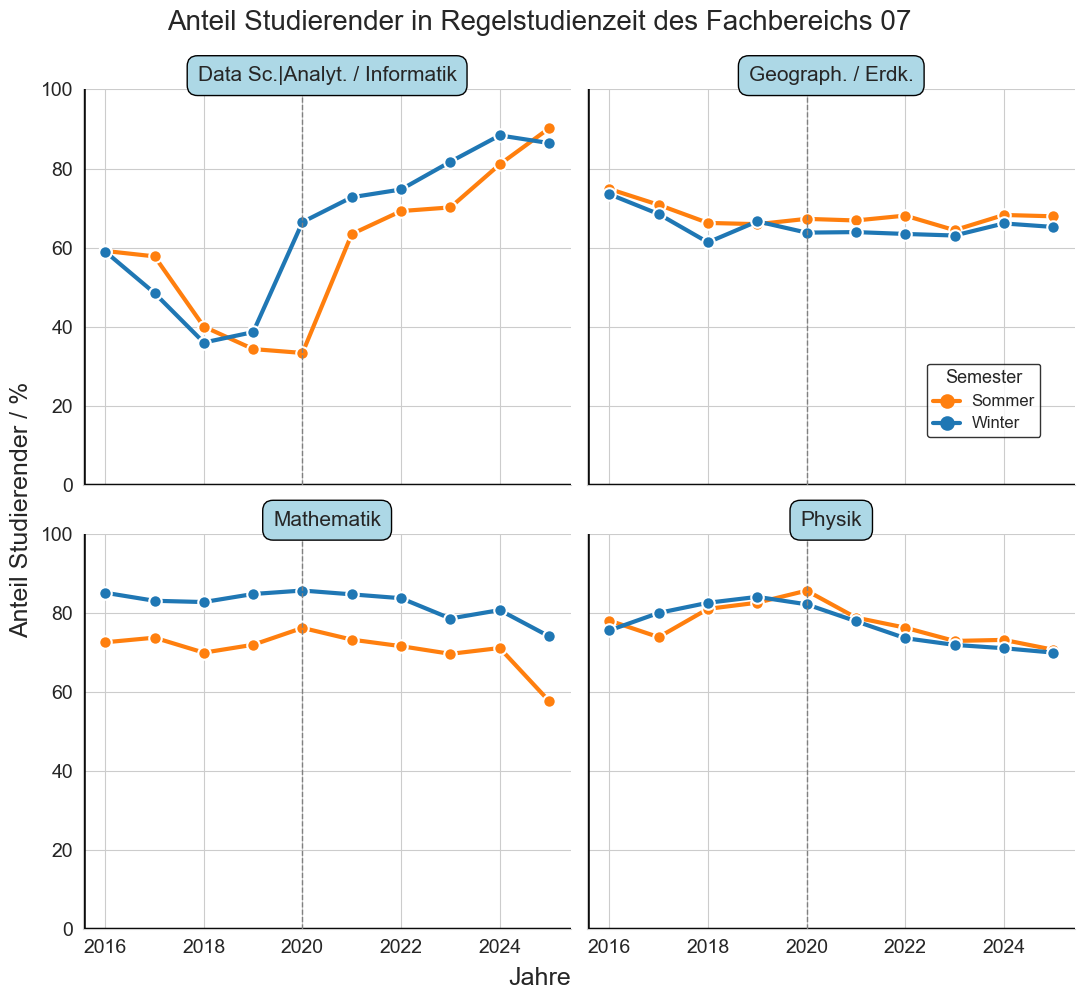

In [6]:
#=== Diagramm erstellen

color_palette = {'Winter': 'tab:blue', 'Sommer': 'tab:orange'}

# Facettiertes liniendiagramm
g = sns.relplot(
    data=df_grp, x="Jahr", y="Anteil",
    hue="Semester", col="Studienfach",
    kind="line", marker="o",
    linewidth=3, markersize=9, markeredgewidth=1.5,
    palette=color_palette, col_wrap=2,
)


#=== Diagramm anpassen

# Einzelne Facetten
for ax in g.axes.flat:
    ax.set_title(ax.get_title().split("=")[-1].strip(), fontsize=15, loc='center', bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='round,pad=0.5'))
    ax.set_yticks(range(0,101, 20))
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('')

## Gesamte Grafik
g.figure.suptitle("Anteil Studierender in Regelstudienzeit des Fachbereichs 07", y=1, fontsize=20)
g.figure.supylabel("Anteil Studierender / %", x = 0.02, fontsize = 18)
g.figure.supxlabel("Jahre", y = 0.02, fontsize = 18)

# Rand der einzelnen Diagramme hervorheben
xmin= ax.get_xlim()[0]
ymin = ax.get_ylim()[0]
for ax in g.axes.flat:
    ax.axvline(x=xmin, color='black', linestyle='-', linewidth=4)
    ax.axhline(y=ymin, color='black', linestyle='-', linewidth=2.5)
    ax.axvline(x=2020, color='grey', linestyle='--', linewidth=1)

# Legende
l = g._legend
frame = l.get_frame()
l.set_bbox_to_anchor((0.95, 0.6))
l.get_title().set_fontsize(13)
for text in l.get_texts(): text.set_fontsize(12)
frame.set_edgecolor('black')
frame.set_visible(True)

plt.tight_layout()
plt.show()